# Retrieving Census Data

In [4]:
import requests
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import shapely.geometry
import cartopy.crs as ccrs
import cartopy
import cfgrib
import datetime as dt
import glob as glob
import matplotlib.pyplot as plt

ImportError: dlopen(/Users/dcalhoun/miniforge3/envs/preprocess/lib/python3.10/site-packages/PIL/_imaging.cpython-310-darwin.so, 0x0002): Library not loaded: @rpath/libtiff.5.dylib
  Referenced from: <2D99D0F6-A7D6-3870-B5B3-8667A21A736E> /Users/dcalhoun/miniforge3/envs/preprocess/lib/python3.10/site-packages/PIL/_imaging.cpython-310-darwin.so
  Reason: tried: '/Users/dcalhoun/miniforge3/envs/preprocess/lib/python3.10/site-packages/PIL/../../../libtiff.5.dylib' (no such file), '/Users/dcalhoun/miniforge3/envs/preprocess/lib/python3.10/site-packages/PIL/../../../libtiff.5.dylib' (no such file), '/Users/dcalhoun/miniforge3/envs/preprocess/bin/../lib/libtiff.5.dylib' (no such file), '/Users/dcalhoun/miniforge3/envs/preprocess/bin/../lib/libtiff.5.dylib' (no such file), '/usr/local/lib/libtiff.5.dylib' (no such file), '/usr/lib/libtiff.5.dylib' (no such file, not in dyld cache)

## By ZCTA

In [2]:
# Retrieve census data
API_KEY = '505d7c44c1572da9b661bb9b5b3e4df82c08ae11'
base_url = 'https://api.census.gov/data/2022/acs/acs5'
variable_names = {
    'B02001_001E': 'Total Population',
    'B02001_002E': 'White Population',
    'B02001_003E': 'Black Population',
    'B02001_005E': 'Asian Population',
    'B02001_004E': 'Native Population',
    'B19013_001E': 'Median Income',
    'B17001_002E': 'Population Below Poverty Line'
}
get_str = 'NAME,' + ','.join(list(variable_names.keys()))
params = {
    'get': get_str,
    'for': 'zip code tabulation area:*',
    'key': API_KEY
}
response = requests.get(base_url, params=params)
if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    for variable in variable_names.keys():
        df[variable] = pd.to_numeric(df[variable])
        df.rename(columns={variable: variable_names[variable]}, inplace=True)
    df.loc[df['Median Income'] < 0, 'Median Income'] = np.nan
    df['Percent White'] = df['White Population'] / df['Total Population'] * 100
    df['Percent Black'] = df['Black Population'] / df['Total Population'] * 100
    df['Percent Asian'] = df['Asian Population'] / df['Total Population'] * 100
    df['Percent Native'] = df['Native Population'] / df['Total Population'] * 100
    df['Poverty Rate'] = df['Population Below Poverty Line'] / df['Total Population'] * 100
else:
    print(f"Error: {response.status_code}")

# Load shapefiles
zctas = gpd.read_file('tl_2022_us_zcta520/tl_2022_us_zcta520.shp')

# Merge data
merged = zctas.merge(df, left_on='ZCTA5CE20', right_on='zip code tabulation area')

In [ ]:
# Regrid data
# Define the grid size in degrees
grid_size = 0.07031256104710337

# Get the bounds of the ZCTA data
xmin, ymin, xmax, ymax = zctas.total_bounds

# Generate the grid
x = np.arange(xmin, xmax, grid_size)
y = np.arange(ymin, ymax, grid_size)
grid_cells = [box(xi, yi, xi + grid_size, yi + grid_size) for xi in x for yi in y]

# Create a GeoDataFrame for the grid cells
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=zctas.crs)

# Spatial join to aggregate ZCTA data within grid cells
joined = gpd.sjoin(grid, merged, how='inner', predicate='within')

# Aggregate median income data within each grid cell
aggregated = joined.groupby(joined.index).agg('mean').reset_index()

# Add aggregated data back to the grid GeoDataFrame
grid['Median Income'] = aggregated['Median Income']

In [ ]:
joined

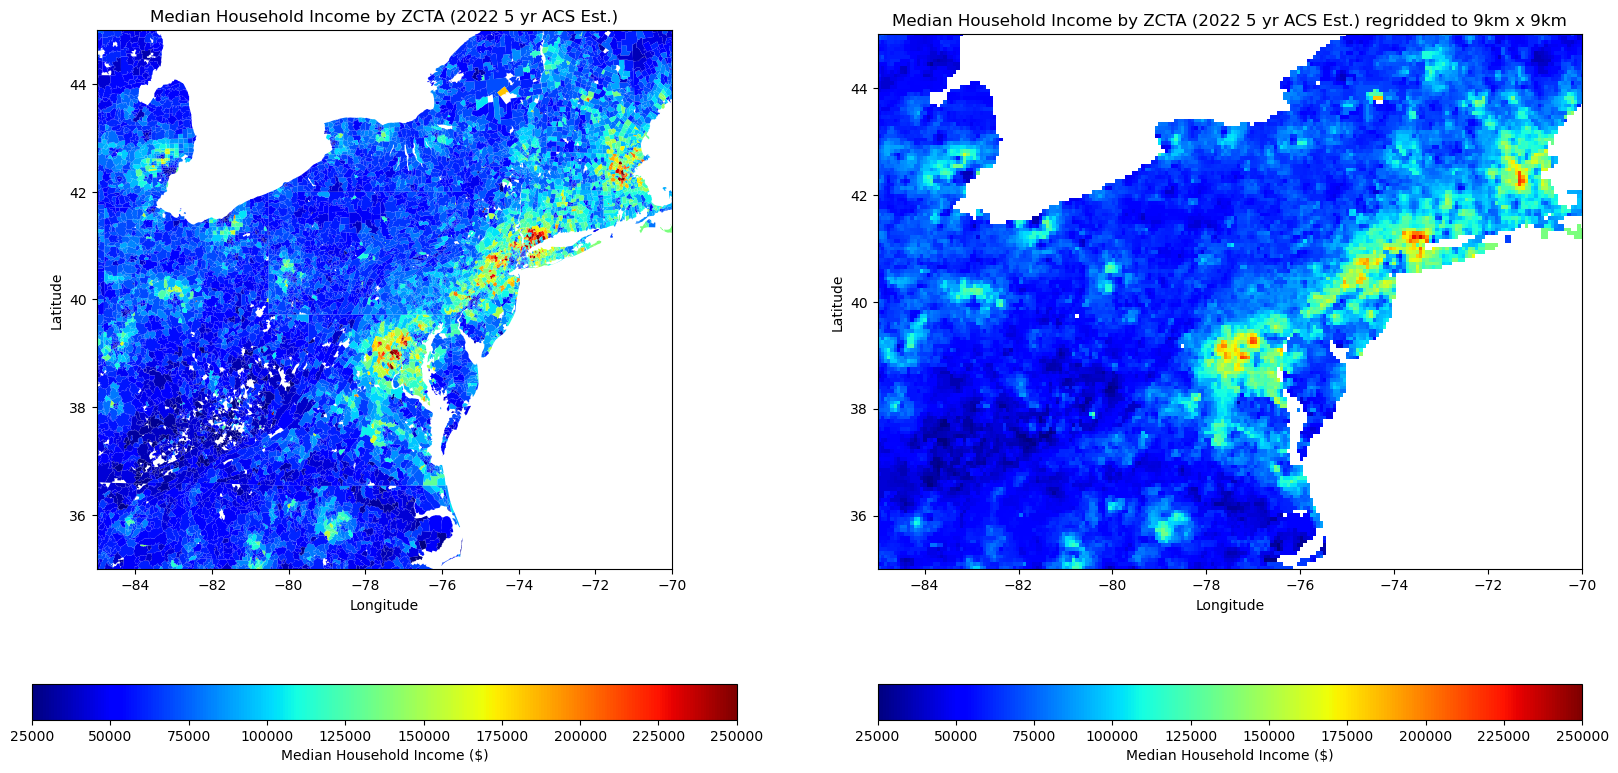

In [4]:
# Plot maps
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
merged.plot(column='Median Income', cmap='jet', linewidth=0, ax=ax[0], vmin = 25000, vmax = 250000, legend=True,
            legend_kwds={'label': "Median Household Income ($)",
                         'orientation': "horizontal"})
bounds = (-85.0, 35.0, -70.0, 45.0)
ax[0].set_xlim(bounds[0], bounds[2])
ax[0].set_ylim(bounds[1], bounds[3])
ax[0].set_title('Median Household Income by ZCTA (2022 5 yr ACS Est.)')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')

grid.plot(column='Median Income', cmap='jet', linewidth=0, ax=ax[1], vmin = 25000, vmax = 250000, legend=True,
            legend_kwds={'label': "Median Household Income ($)",
                         'orientation': "horizontal"})
ax[1].set_xlim(bounds[0], bounds[2])
ax[1].set_ylim(bounds[1], bounds[3])
ax[1].set_title('Median Household Income by ZCTA (2022 5 yr ACS Est.) regridded to 9km x 9km')
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')
# plt.savefig('zcta_map.png', dpi=600)
plt.show()

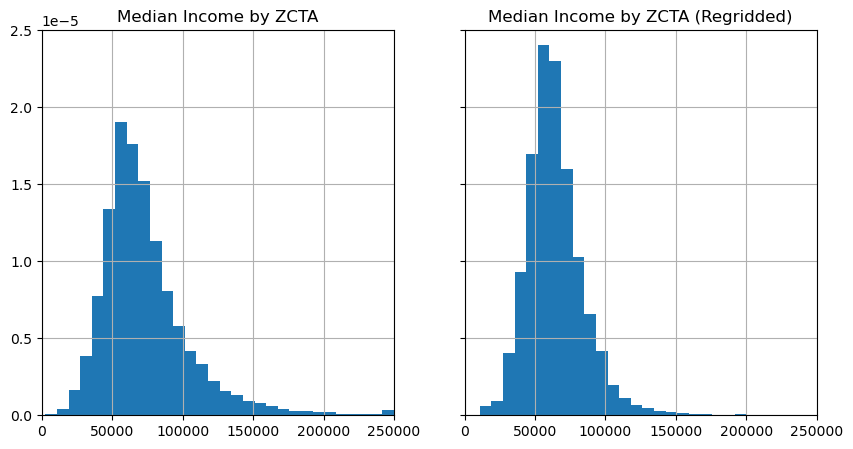

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
df['Median Income'].hist(bins=30, density=True, ax=ax[0])
grid[-np.isnan(grid['Median Income'])]['Median Income'].hist(bins=30, density=True, ax=ax[1])
plt.xlim(0,250000)
plt.ylim(0, 2.5e-5)
ax[0].set_title('Median Income by ZCTA')
ax[1].set_title('Median Income by ZCTA (Regridded)')
# plt.savefig('zcta_hist.png', dpi=600)
plt.show()

In [ ]:
# Regrid data
# Define the grid size in degrees
grid_size = 0.07031256104710337

# Get the bounds of the ZCTA data
xmin, ymin, xmax, ymax = zctas.total_bounds

# Generate the grid
x = np.arange(xmin, xmax, grid_size)
y = np.arange(ymin, ymax, grid_size)
grid_cells = [box(xi, yi, xi + grid_size, yi + grid_size) for xi in x for yi in y]

# Create a GeoDataFrame for the grid cells
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=zctas.crs)

# Spatial join to aggregate ZCTA data within grid cells
joined = gpd.sjoin(grid, merged, how='left', predicate='intersects')

# Aggregate data within each grid cell
aggregated = joined.groupby(joined.index).agg({
    'Poverty Rate': 'mean'
}).reset_index()

# Add aggregated data back to the grid GeoDataFrame
grid['Poverty Rate'] = aggregated['Poverty Rate']

In [ ]:
# Plot maps
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
merged.plot(column='Poverty Rate', cmap='jet', linewidth=0, ax=ax[0], vmin = 25000, vmax = 250000, legend=True,
            legend_kwds={'label': "Median Household Income ($)",
                         'orientation': "horizontal"})
bounds = (-85.0, 35.0, -70.0, 45.0)
ax[0].set_xlim(bounds[0], bounds[2])
ax[0].set_ylim(bounds[1], bounds[3])
ax[0].set_title('Median Household Income by ZCTA (2022 5 yr ACS Est.)')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')

grid.plot(column='Median Income', cmap='jet', linewidth=0, ax=ax[1], vmin = 25000, vmax = 250000, legend=True,
            legend_kwds={'label': "Median Household Income ($)",
                         'orientation': "horizontal"})
ax[1].set_xlim(bounds[0], bounds[2])
ax[1].set_ylim(bounds[1], bounds[3])
ax[1].set_title('Median Household Income by ZCTA (2022 5 yr ACS Est.) regridded to 9km x 9km')
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')
# plt.savefig('zcta_map.png', dpi=600)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
df['Median Income'].hist(bins=30, density=True, ax=ax[0])
grid[-np.isnan(grid['Median Income'])]['Median Income'].hist(bins=30, density=True, ax=ax[1])
plt.xlim(0,250000)
plt.ylim(0, 2.5e-5)
ax[0].set_title('Median Income by ZCTA')
ax[1].set_title('Median Income by ZCTA (Regridded)')
# plt.savefig('zcta_hist.png', dpi=600)
plt.show()

# By census tract

In [16]:
# Retrieve census data
API_KEY = '505d7c44c1572da9b661bb9b5b3e4df82c08ae11'
base_url = 'https://api.census.gov/data/2022/acs/acs5'
fips = ['09','10','11','18','21','23','24','25','26','33','34','36','37','39','42','44','47','50','51','54']
variable_names = {
    'B02001_001E': 'Total Population',
    'B02001_002E': 'White Population',
    'B02001_003E': 'Black Population',
    'B02001_005E': 'Asian Population',
    'B02001_004E': 'Native Population',
    'B19013_001E': 'Median Income',
    'B17001_002E': 'Population Below Poverty Line'
}
get_str = 'NAME,' + ','.join(list(variable_names.keys()))
df = pd.DataFrame()
for code in fips:
    params = {
        'get': get_str,
        'for': 'tract:*',
        'in': f'state:{code}',
        'key': API_KEY
    }

    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        data = response.json()
        tmp = pd.DataFrame(data[1:], columns=data[0])
        for variable in variable_names.keys():
            tmp[variable] = pd.to_numeric(tmp[variable])
            tmp.rename(columns={variable: variable_names[variable]}, inplace=True)
        tmp.loc[tmp['Median Income'] < 0, 'Median Income'] = np.nan
        df = pd.concat([df, tmp])
    else:
        print(f"Error: {response.status_code}")
df['Percent White'] = df['White Population'] / df['Total Population'] * 100
df['Percent Black'] = df['Black Population'] / df['Total Population'] * 100
df['Percent Asian'] = df['Asian Population'] / df['Total Population'] * 100
df['Percent Native'] = df['Native Population'] / df['Total Population'] * 100
df['Poverty Rate'] = df['Population Below Poverty Line'] / df['Total Population'] * 100
cols = df.columns.tolist()
cols = [cols[0]] + cols[8:11] + cols[1:8] + cols[11:]
df = df[cols]

# Load shapefiles
tracts = pd.DataFrame()
for code in fips:
    tmp = gpd.read_file(f'Data/TIGER/tl_2022_{code}_tract/tl_2022_{code}_tract.shp')
    tracts = pd.concat([tracts,tmp])

# Merge data with shapefiles
merged = tracts.merge(df, left_on='TRACTCE', right_on='tract')

# Normalize by area
merged['Total Population Density'] = merged['Total Population'] / merged['ALAND'] / 1000
merged['White Population Density'] = merged['White Population'] / merged['ALAND'] / 1000
merged['Black Population Density'] = merged['Black Population'] / merged['ALAND'] / 1000
merged['Asian Population Density'] = merged['Asian Population'] / merged['ALAND'] / 1000
merged['Native Population Density'] = merged['Native Population'] / merged['ALAND'] / 1000

In [ ]:
# Regrid data
# Define the grid size in degrees
grid_size = 0.07031256104710337

# Get the bounds of the tract data
xmin, ymin, xmax, ymax = tracts.total_bounds

# Generate the grid
x = np.arange(xmin, xmax, grid_size)åå
y = np.arange(ymin, ymax, grid_size)
grid_cells = [box(xi, yi, xi + grid_size, yi + grid_size) for xi in x for yi in y]

# Create a GeoDataFrame for the grid cells
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=tracts.crs)

# Spatial join to aggregate tract data within grid cells
joined = gpd.sjoin(grid, merged, how='left', predicate='intersects')

# Aggregate median income data within each grid cell
aggregated = joined.groupby(joined.index).agg({
    'Median Income': 'mean'
}).reset_index()

# Add aggregated data back to the grid GeoDataFrame
grid['Median Income'] = aggregated['Median Income']

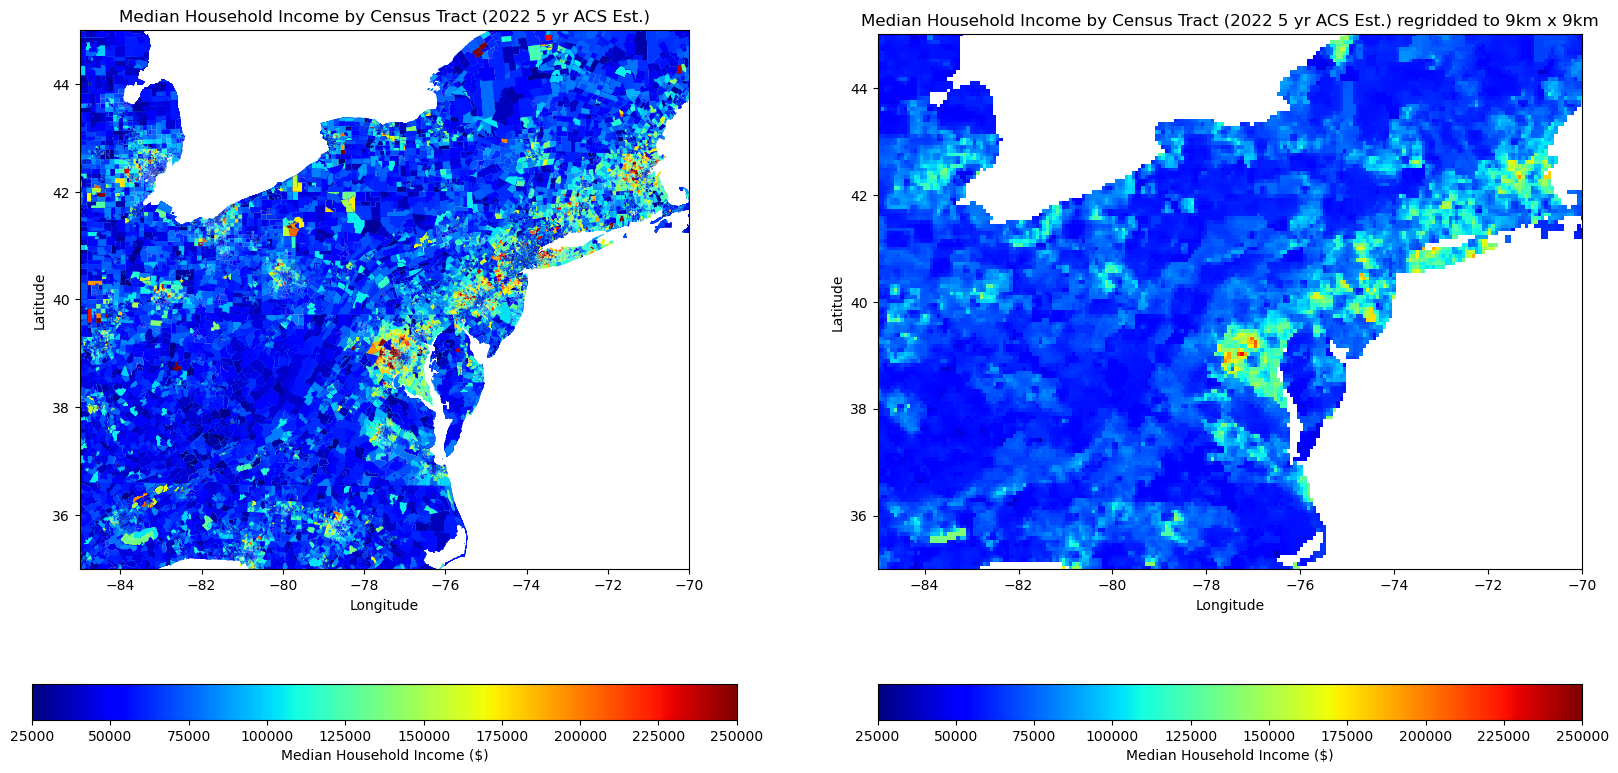

In [8]:
# Plot maps
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
merged.plot(column='Median Income', cmap='jet', linewidth=0, ax=ax[0], vmin = 25000, vmax = 250000, legend=True,
            legend_kwds={'label': "Median Household Income ($)",
                         'orientation': "horizontal"})
bounds = (-85.0, 35.0, -70.0, 45.0)
ax[0].set_xlim(bounds[0], bounds[2])
ax[0].set_ylim(bounds[1], bounds[3])
ax[0].set_title('Median Household Income by Census Tract (2022 5 yr ACS Est.)')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')

grid.plot(column='Median Income', cmap='jet', linewidth=0, ax=ax[1], vmin = 25000, vmax = 250000, legend=True,
            legend_kwds={'label': "Median Household Income ($)",
                         'orientation': "horizontal"})
ax[1].set_xlim(bounds[0], bounds[2])
ax[1].set_ylim(bounds[1], bounds[3])
ax[1].set_title('Median Household Income by Census Tract (2022 5 yr ACS Est.) regridded to 9km x 9km')
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')
# plt.savefig('tract_map.png', dpi=600)
plt.show()

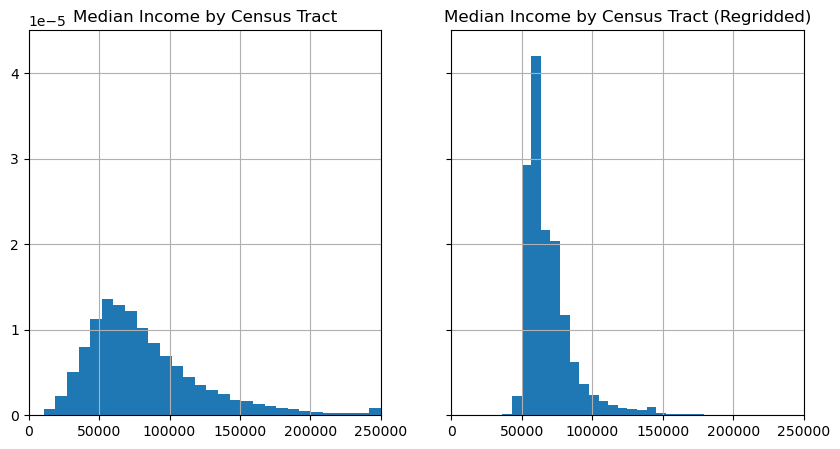

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
df['Median Income'].hist(bins=30, density=True, ax=ax[0])
grid[-np.isnan(grid['Median Income'])]['Median Income'].hist(bins=30, density=True, ax=ax[1])
plt.xlim(0,250000)
plt.ylim(0, 4.5e-5)
ax[0].set_title('Median Income by Census Tract')
ax[1].set_title('Median Income by Census Tract (Regridded)')
# plt.savefig('tract_hist.png', dpi=600)
plt.show()

# Statistical stuff

In [139]:
xmax = np.max(df['Median Income'])
xmin = np.min(df['Median Income'])
N = 5000
x = np.linspace(int(xmin), int(xmax), int(np.ceil((xmax-xmin)/N)))
y_tot = np.zeros(len(x))
y_w = np.zeros(len(x))
y_b = np.zeros(len(x))
for i in range(len(x)-1):
    y_tot[i] = df[(df['Median Income']>=x[i]) & (df['Median Income']<=x[i+1])]['Total Population'].sum()/df['Total Population'].sum()
    y_w[i] = df[(df['Median Income']>=x[i]) & (df['Median Income']<=x[i+1])]['White Population'].sum()/df['White Population'].sum()
    y_b[i] = df[(df['Median Income']>=x[i]) & (df['Median Income']<=x[i+1])]['Black Population'].sum()/df['Black Population'].sum()

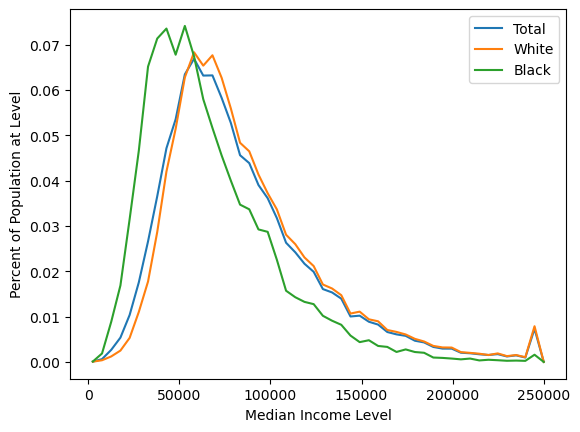

In [140]:
plt.plot(x, y_tot, label='Total')
plt.plot(x, y_w, label='White')
plt.plot(x, y_b, label='Black')
plt.xlabel('Median Income Level')
plt.ylabel('Percent of Population at Level')
plt.legend()
plt.show()

In [161]:
quantiles = np.arange(0,1.01,0.05)
incomes = np.zeros(len(quantiles))
for i in range(len(quantiles)):
    incomes[i] = np.nanquantile(df['Median Income'].values, quantiles[i])
x = incomes
y_tot = np.zeros(len(x))
y_w = np.zeros(len(x))
y_b = np.zeros(len(x))
for i in range(len(x)-1):
    y_tot[i] = df[(df['Median Income']>=x[i]) & (df['Median Income']<=x[i+1])]['Total Population'].sum()/df['Total Population'].sum()
    y_w[i] = df[(df['Median Income']>=x[i]) & (df['Median Income']<=x[i+1])]['White Population'].sum()/df['White Population'].sum()
    y_b[i] = df[(df['Median Income']>=x[i]) & (df['Median Income']<=x[i+1])]['Black Population'].sum()/df['Black Population'].sum()

y_tot[-1] = df[df['Median Income']>=x[-1]]['Total Population'].sum()/df['Total Population'].sum()
y_w[-1] = df[df['Median Income']>=x[-1]]['White Population'].sum()/df['White Population'].sum()
y_b[-1] = df[df['Median Income']>=x[-1]]['Black Population'].sum()/df['Black Population'].sum()

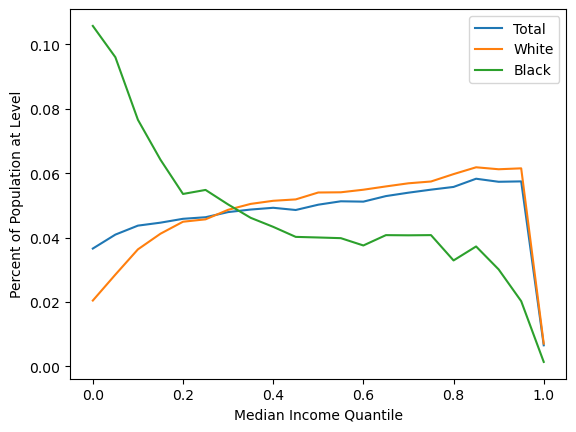

In [162]:
plt.plot(quantiles, y_tot, label='Total')
plt.plot(quantiles, y_w, label='White')
plt.plot(quantiles, y_b, label='Black')
plt.xlabel('Median Income Quantile')
plt.ylabel('Percent of Population at Level')
plt.legend()
plt.show()

# Try to align IFS grid

In [3]:
def subset(ds):
    min_lon = -85
    max_lon = -70
    min_lat = 35
    max_lat = 45
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby('longitude').sortby('latitude')
    ds = ds.sel(latitude=slice(min_lat,max_lat), longitude=slice(min_lon,max_lon))
    return ds

In [4]:
# Load and process the data
ifs_filenames = glob.glob('Data/IFS_2016_2023_6hr/*2t*.grb')
ifs_filenames = sorted(ifs_filenames)
ifs_t2m = subset(xr.open_dataset(ifs_filenames[0], engine="cfgrib"))
for file in ifs_filenames[1:]:
    tmp = subset(xr.open_dataset(file, engine="cfgrib"))
    ifs_t2m = xr.concat([ifs_t2m, tmp], 'time')
ifs_t2m -= 273.15
era_t2m, era_tp = cfgrib.open_datasets('Data/era_t2m_tp_2016.grib')
era_t2m = subset(era_t2m) - 273.15
era_t2m_fine = era_t2m.interp(latitude=ifs_t2m.latitude, longitude = ifs_t2m.longitude)

nt = len(era_t2m.valid_time)-1
nlat = len(ifs_t2m.latitude)
nlon = len(ifs_t2m.longitude)
latitudes = ifs_t2m.latitude.values
longitudes = ifs_t2m.longitude.values
times = pd.date_range(start=ifs_t2m.valid_time[0].values[0], end=era_t2m.valid_time.values[-1], freq='6h')

In [6]:
grid_cells = [shapely.Point(lati, loni) for lati in latitudes for loni in longitudes]

In [7]:
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=tracts.crs)

In [33]:
grid['Sample'] = np.random.randint(0,100,len(grid))

In [8]:
grid

,geometry
0,POINT (35.04394 -84.93726)
1,POINT (35.04394 -84.86695)
2,POINT (35.04394 -84.79664)
3,POINT (35.04394 -84.72632)
4,POINT (35.04394 -84.65601)
...,...
30241,POINT (44.95606 -70.31225)
30242,POINT (44.95606 -70.24194)
30243,POINT (44.95606 -70.17162)
30244,POINT (44.95606 -70.10131)


In [15]:
merged['ALAND'].max()

7800650637

In [ ]:
# Regrid data
# Define the grid size in degrees
grid_size = 0.07031256104710337

# Get the bounds of the ZCTA data
xmin, ymin, xmax, ymax = tracts.total_bounds

# Generate the grid
x = np.arange(xmin, xmax, grid_size)
y = np.arange(ymin, ymax, grid_size)
grid_cells = [point(lati, loni) for lati in latitudes for yi in longitudes]

# Create a GeoDataFrame for the grid cells
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=tracts.crs)

In [27]:
shapely.geometry.point

<module 'shapely.geometry.point' from '/opt/anaconda3/envs/pareto/lib/python3.8/site-packages/shapely/geometry/point.py'>

In [58]:
foo = np.array(grid['Sample']).reshape(nlat,nlon)

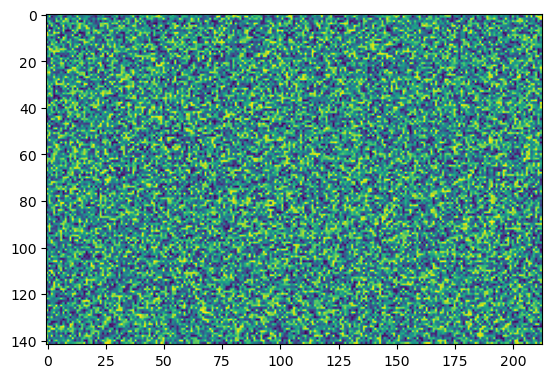

In [62]:
plt.imshow(foo)
plt.show()

In [53]:
grid

,geometry,Sample
0,POINT (35.04394 -84.93726),62
1,POINT (35.04394 -84.86695),45
2,POINT (35.04394 -84.79664),61
3,POINT (35.04394 -84.72632),14
4,POINT (35.04394 -84.65601),3
...,...,...
30241,POINT (44.95606 -70.31225),43
30242,POINT (44.95606 -70.24194),55
30243,POINT (44.95606 -70.17162),93
30244,POINT (44.95606 -70.10131),34


In [73]:
# Spatial join to aggregate ZCTA data within grid cells
joined = gpd.sjoin(grid, merged, how='left', predicate='intersects')

# # Aggregate median income data within each grid cell
# aggregated = joined.groupby(joined.index).agg('mean').reset_index()

# # Add aggregated data back to the grid GeoDataFrame
# grid['Median Income'] = aggregated['Median Income']

In [82]:
merged.loc[1000]

ZCTA5CE20                                                                    46740
GEOID20                                                                      46740
CLASSFP20                                                                       B5
MTFCC20                                                                      G6350
FUNCSTAT20                                                                       S
ALAND20                                                                  161303013
AWATER20                                                                   1213972
INTPTLAT20                                                             +40.6042800
INTPTLON20                                                            -084.9647618
geometry                         POLYGON ((-85.12608400000001 40.574804, -85.12...
NAME                                                                   ZCTA5 46740
Total Population                                                              4586
Whit

In [27]:
from itertools import product

In [42]:
# create state mask based on 5x5-km netcdf grid
mask = np.zeros((nlat, nlon))

for i, j in product(range(nlat), range(nlon)):
    
    # if the region shapefile contains that lat/lon value, assign value of 1, 
    # otherwise leave as zero
    if region.contains(shapely.Point(longitudes[j], latitudes[i])).any():
        
        mask[i,j] = 1

In [37]:
mask.max()

1.0

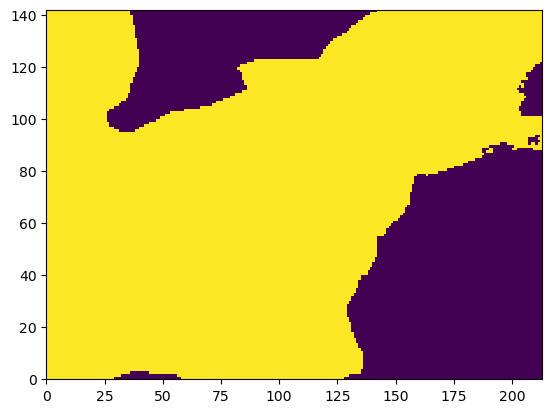

In [43]:
plt.pcolormesh(mask); plt.show()

In [19]:
tracts

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,09,110,504200,09110504200,5042,Census Tract 5042,G5020,S,1168181,0,+41.7677280,-072.7066460,"POLYGON ((-72.71188 41.77023, -72.71185 41.770..."
1,09,110,504300,09110504300,5043,Census Tract 5043,G5020,S,727281,0,+41.7520159,-072.7111189,"POLYGON ((-72.71537 41.74435, -72.71530 41.744..."
2,09,110,504500,09110504500,5045,Census Tract 5045,G5020,S,772018,0,+41.7408493,-072.6997041,"POLYGON ((-72.70645 41.73512, -72.70574 41.735..."
3,09,110,504100,09110504100,5041,Census Tract 5041,G5020,S,286070,0,+41.7592478,-072.7048251,"POLYGON ((-72.70945 41.76040, -72.70909 41.760..."
4,09,110,504900,09110504900,5049,Census Tract 5049,G5020,S,1556383,0,+41.7489889,-072.7034372,"POLYGON ((-72.71514 41.74260, -72.71403 41.743..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,54,079,020500,54079020500,205,Census Tract 205,G5020,S,59496880,1981139,+38.4862619,-081.7847857,"POLYGON ((-81.85198 38.42948, -81.85192 38.430..."
542,54,079,020700,54079020700,207,Census Tract 207,G5020,S,160266011,254494,+38.3811455,-081.9720724,"POLYGON ((-82.05142 38.41964, -82.05111 38.419..."
543,54,061,010202,54061010202,102.02,Census Tract 102.02,G5020,S,1066311,0,+39.6448580,-079.9505516,"POLYGON ((-79.95833 39.64294, -79.95829 39.643..."
544,54,101,970102,54101970102,9701.02,Census Tract 9701.02,G5020,S,420676844,1371888,+38.6168540,-080.3868135,"POLYGON ((-80.54400 38.61600, -80.54389 38.616..."


In [20]:
region = gpd.read_file('Data/TIGER/tl_2023_us_state/tl_2023_us_state.shp')

In [24]:
region = region[region['STATEFP'].isin(fips)]

In [40]:
region

,REGION,DIVISION,STATEFP,STATENS,GEOID,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,3,5,54,01779805,54,0400000US54,WV,West Virginia,00,G4000,A,62266499712,489003081,+38.6472854,-080.6183274,"POLYGON ((-77.75438 39.33346, -77.75422 39.333..."
4,3,5,24,01714934,24,0400000US24,MD,Maryland,00,G4000,A,25151736098,6979330958,+38.9466584,-076.6744939,"POLYGON ((-75.75600 39.24607, -75.75579 39.243..."
5,1,1,44,01219835,44,0400000US44,RI,Rhode Island,00,G4000,A,2677763372,1323686976,+41.5964850,-071.5264901,"MULTIPOLYGON (((-71.67881 41.15891, -71.67626 ..."
7,1,1,33,01779794,33,0400000US33,NH,New Hampshire,00,G4000,A,23190126365,1025956733,+43.6727945,-071.5841886,"POLYGON ((-70.83887 43.24449, -70.83886 43.244..."
8,3,5,37,01027616,37,0400000US37,NC,North Carolina,00,G4000,A,125935880061,13453540851,+35.5397100,-079.1308636,"POLYGON ((-77.89977 36.54460, -77.89942 36.544..."
9,1,1,50,01779802,50,0400000US50,VT,Vermont,00,G4000,A,23872589127,1030648383,+44.0589536,-072.6710173,"POLYGON ((-72.04187 44.15665, -72.04180 44.156..."
10,1,1,09,01779780,09,0400000US09,CT,Connecticut,00,G4000,A,12541750274,1816364426,+41.5798637,-072.7466572,"POLYGON ((-72.52790 41.17777, -72.55156 41.173..."
11,3,5,10,01779781,10,0400000US10,DE,Delaware,00,G4000,A,5046703781,1399207462,+38.9985661,-075.4416440,"POLYGON ((-75.50949 39.68652, -75.50942 39.686..."
14,1,2,34,01779795,34,0400000US34,NJ,New Jersey,00,G4000,A,19049183398,3532816229,+40.1072744,-074.6652012,"POLYGON ((-74.46493 39.29823, -74.46906 39.294..."
18,1,2,42,01779798,42,0400000US42,PA,Pennsylvania,00,G4000,A,115881839569,3397855215,+40.9046042,-077.8275233,"POLYGON ((-75.59310 39.83772, -75.59319 39.837..."
